# Statistical Analysis
**Answers:** D3, D4, D5, S1-S4 · Notes: P3 - Statistical Analysis
**Input:** `reports/tables/orders_clean.csv` (from `data_cleaning.ipynb`)
**Population:** delivered orders purchased 2017-01 .. 2018-08 with a delivery date (same as `analytics.delivery_orders` in SQL)
**Definitions:** late = delivered date > estimated date · review score = latest review of the order

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", "{:,.3f}".format)

RAW = Path("../data/raw")
TABLES = Path("../reports/tables")
FIGS = Path("../reports/figures")
TABLES.mkdir(parents=True, exist_ok=True)
FIGS.mkdir(parents=True, exist_ok=True)
from scipy import stats

In [2]:
# Chart style: recessive grid/axes, thin marks, text in neutral ink (never series colour)
BLUE, ORANGE = "#2a78d6", "#eb6834"      # on-time / main series = blue, late = orange (validated pair)
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e5e4e0"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "figure.facecolor": "white",
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK2, "ytick.color": INK2, "legend.frameon": False,
    "font.size": 10,
})

def save(fig, name):
    fig.savefig(FIGS / name, bbox_inches="tight")
    print("saved", FIGS / name)

In [3]:
orders = pd.read_csv(TABLES / "orders_clean.csv", parse_dates=["purchase_month"])
dlv = orders[orders["in_kpi_period"] & orders["has_delivery_date"]].copy()
dlv["status"] = np.where(dlv["is_late"] == 1, "late", "on time")
rev = dlv.dropna(subset=["review_score"])
print("delivered orders:", len(dlv), "| with review:", len(rev))

rng = np.random.default_rng(42)
N_BOOT = 2000

delivered orders: 96203 | with review: 95560


## Part A - Delivery time
### A1. Distribution
**Question:** what is the shape of `delivery_days`?

In [4]:
x = dlv["delivery_days"].to_numpy()
summary = pd.Series({"n": len(x), "mean": x.mean(), "median": np.median(x),
                     "p90": np.percentile(x, 90), "p99": np.percentile(x, 99),
                     "max": x.max(), "skewness": stats.skew(x)})
summary.round(2)

n          96,203.000
mean           12.540
median         10.210
p90            23.060
p99            46.010
max           209.630
skewness        3.850
dtype: float64

saved ../reports/figures/del_delivery_days_hist.png


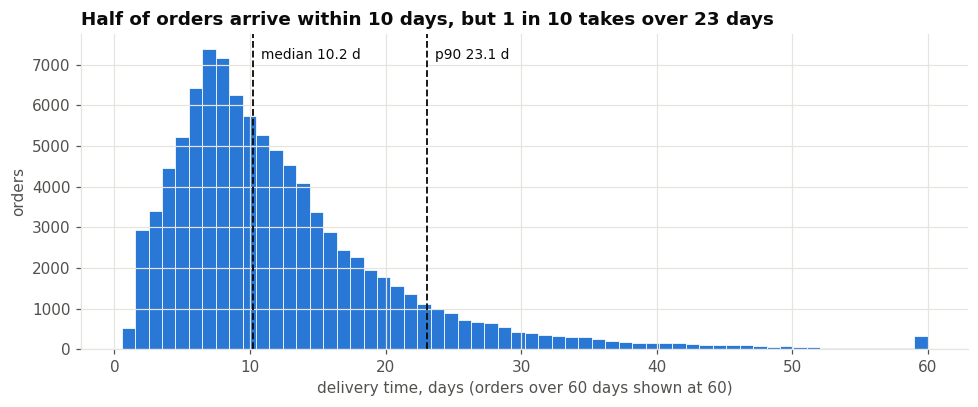

In [5]:
med, p90 = np.median(x), np.percentile(x, 90)
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.hist(np.clip(x, 0, 60), bins=60, color=BLUE, edgecolor="white", linewidth=0.5)
for v, lab in [(med, f"median {med:.1f} d"), (p90, f"p90 {p90:.1f} d")]:
    ax.axvline(v, color=INK, linewidth=1.2, linestyle="--")
    ax.text(v + 0.6, ax.get_ylim()[1] * 0.92, lab, color=INK, fontsize=9)
ax.set_xlabel("delivery time, days (orders over 60 days shown at 60)")
ax.set_ylabel("orders")
ax.set_title(f"Half of orders arrive within {med:.0f} days, but 1 in 10 takes over {p90:.0f} days")
fig.tight_layout()
save(fig, "del_delivery_days_hist.png")

**Finding:** Delivery time is strongly right-skewed (skewness 3.85): mean 12.5 days vs median 10.2, p90 23.1, p99 46.0 days (96,203 delivered orders). The mean is pulled up by the long tail, so median and p90 are the right summary.

### A2. Bootstrap CIs for the median and p90
**Why bootstrap:** delivery time is strongly right-skewed and there is no simple formula for the CI of a 90th percentile. The bootstrap resamples the orders with replacement many times and looks at how much the statistic moves.

In [6]:
def bootstrap_ci(values, stat_fn, n_boot=N_BOOT, level=0.95, rng=rng):
    """Percentile bootstrap: resample with replacement, recompute the statistic, take the middle 95%."""
    values = np.asarray(values)
    boots = np.empty(n_boot)
    for i in range(n_boot):
        sample = rng.choice(values, size=len(values), replace=True)
        boots[i] = stat_fn(sample)
    alpha = (1 - level) / 2
    return stat_fn(values), np.quantile(boots, alpha), np.quantile(boots, 1 - alpha)

p90_fn = lambda v: np.percentile(v, 90)
ci_table = pd.DataFrame(
    [bootstrap_ci(x, np.median), bootstrap_ci(x, p90_fn)],
    index=["median delivery days", "p90 delivery days"], columns=["estimate", "ci_low", "ci_high"])
ci_table.round(2)

,estimate,ci_low,ci_high
median delivery days,10.210,10.170,10.260
p90 delivery days,23.060,22.930,23.170


In [7]:
# Cross-check my own bootstrap with SciPy's implementation (median only - it is the slower one to vectorise)
res = stats.bootstrap((x,), np.median, n_resamples=1000, confidence_level=0.95,
                      method="percentile", batch=50, rng=np.random.default_rng(7))
print("SciPy percentile CI for the median:", np.round(res.confidence_interval, 2))

SciPy percentile CI for the median: [10.17 10.25]


**Finding:** With 96k orders both estimates are precise: median 10.21 days (95% CI 10.17-10.26), p90 23.06 days (95% CI 22.93-23.17). SciPy's bootstrap gives the same interval for the median.

### A3. The worst states, with CIs
**Question:** are the slowest states clearly different from the national value, or could it be noise? (States with >= 300 delivered orders; the 5 highest late rates.)

In [8]:
state_stats = (dlv.groupby("customer_state")
                  .agg(orders=("order_id", "size"), late_rate=("is_late", "mean"))
                  .query("orders >= 300")
                  .sort_values("late_rate", ascending=False))
worst = state_stats.head(5).index

rows = []
for st in worst:
    v = dlv.loc[dlv["customer_state"] == st, "delivery_days"].to_numpy()
    m, m_lo, m_hi = bootstrap_ci(v, np.median, n_boot=1000)
    q, q_lo, q_hi = bootstrap_ci(v, p90_fn, n_boot=1000)
    rows.append({"state": st, "orders": len(v), "late_pct": 100 * state_stats.loc[st, "late_rate"],
                 "median": m, "median_ci": f"[{m_lo:.1f}, {m_hi:.1f}]",
                 "p90": q, "p90_ci": f"[{q_lo:.1f}, {q_hi:.1f}]"})
worst_table = pd.DataFrame(rows).set_index("state")
print(f"national: median {med:.1f} days, p90 {p90:.1f} days, late {100 * dlv['is_late'].mean():.1f}%")
worst_table.round(1)

national: median 10.2 days, p90 23.1 days, late 6.8%


,orders,late_pct,median,median_ci,p90,p90_ci
state,,,,,,
AL,396,21.500,22.300,"[20.8, 23.9]",39.600,"[37.2, 43.4]"
MA,713,17.500,19.200,"[18.5, 19.8]",34.200,"[32.7, 36.8]"
SE,332,15.400,17.900,"[17.0, 19.0]",35.400,"[32.4, 38.9]"
PI,475,13.900,16.300,"[15.3, 17.6]",30.100,"[27.7, 33.1]"
CE,1273,13.800,18.200,"[17.9, 18.5]",34.700,"[32.6, 37.1]"


**Finding:** The five states with the highest late rates (AL, MA, SE, PI, CE - all in the North-East) also have much longer deliveries: median 16-22 days and p90 30-40 days vs 10.2 / 23.1 nationally. Every CI lies far above the national value, so the difference is not sampling noise.

## Part B - Review score: on-time vs late
### B1. Describe before testing

In [9]:
def describe_scores(s):
    return pd.Series({"n": len(s), "mean": s.mean(), "median": s.median(),
                      "pct_1_2_stars": 100 * (s <= 2).mean(), "pct_5_stars": 100 * (s == 5).mean(),
                      "std": s.std()})

groups = rev.groupby("status")["review_score"].apply(describe_scores).unstack()
groups.loc["difference (late - on time)"] = groups.loc["late"] - groups.loc["on time"]
groups.loc["difference (late - on time)", "n"] = np.nan
print("S1 - all reviews: mean", round(rev["review_score"].mean(), 3), "| median", rev["review_score"].median())
groups.round(3)

S1 - all reviews: mean 4.156 | median 5.0


,n,mean,median,pct_1_2_stars,pct_5_stars,std
status,,,,,,
late,"6,378.000",2.271,1.000,62.418,16.541,1.571
on time,"89,182.000",4.291,5.000,9.247,62.283,1.148
difference (late - on time),NaN,-2.021,-4.000,53.170,-45.742,0.423


saved ../reports/figures/sat_review_distribution_on_time_vs_late.png


review_score,1.000,2.000,3.000,4.000,5.000
status,,,,,
on time,6.600,2.600,8.100,20.400,62.300
late,53.800,8.700,10.900,10.200,16.500


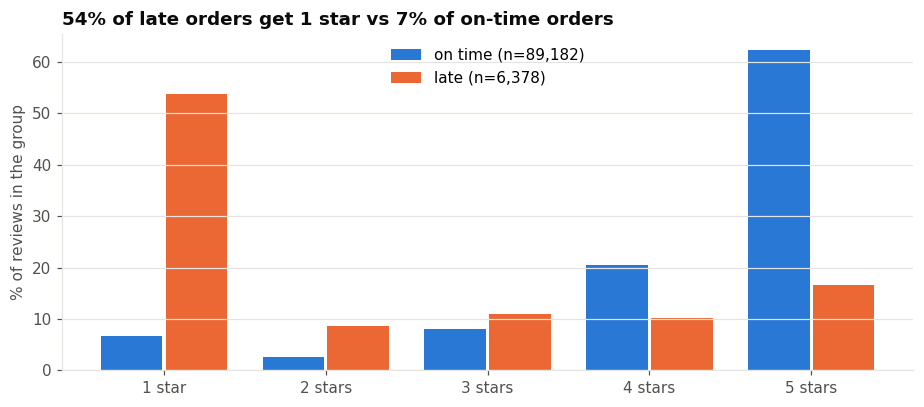

In [10]:
dist = (pd.crosstab(rev["status"], rev["review_score"], normalize="index") * 100).loc[["on time", "late"]]
fig, ax = plt.subplots(figsize=(8.5, 3.8))
xs = np.arange(1, 6)
w = 0.38
ax.bar(xs - w/2 - 0.01, dist.loc["on time"], width=w, color=BLUE, label=f"on time (n={groups.loc['on time','n']:,.0f})")
ax.bar(xs + w/2 + 0.01, dist.loc["late"], width=w, color=ORANGE, label=f"late (n={groups.loc['late','n']:,.0f})")
ax.set_xticks(xs, [f"{i} star" + ("s" if i > 1 else "") for i in xs])
ax.set_ylabel("% of reviews in the group")
ax.grid(axis="x", visible=False)
ax.legend(loc="upper center")
ax.set_title(f"{dist.loc['late', 1]:.0f}% of late orders get 1 star vs {dist.loc['on time', 1]:.0f}% of on-time orders")
fig.tight_layout()
save(fig, "sat_review_distribution_on_time_vs_late.png")
dist.round(1)

### B2. Characteristics of the data -> choice of method

In [11]:
late_s = rev.loc[rev["status"] == "late", "review_score"].to_numpy()
ontime_s = rev.loc[rev["status"] == "on time", "review_score"].to_numpy()
pd.Series({
    "distinct values of the outcome": rev["review_score"].nunique(),
    "n on time": len(ontime_s), "n late": len(late_s),
    "ratio of group sizes": len(ontime_s) / len(late_s),
    "std on time": ontime_s.std(ddof=1), "std late": late_s.std(ddof=1),
    "skewness on time": stats.skew(ontime_s), "skewness late": stats.skew(late_s),
    "customers with > 1 order in this population": (rev.groupby("customer_unique_id").size() > 1).sum(),
}).round(3)

distinct values of the outcome                     5.000
n on time                                     89,182.000
n late                                         6,378.000
ratio of group sizes                              13.983
std on time                                        1.148
std late                                           1.571
skewness on time                                  -1.735
skewness late                                      0.729
customers with > 1 order in this population    2,752.000
dtype: float64

| Characteristic | What the data shows | Consequence |
| --- | --- | --- |
| Scale | 1-5 stars, 5 distinct values -> **ordinal** | a mean difference is readable as "average stars", but medians can only jump between whole stars |
| Shape | on-time scores pile up at 5 (left-skewed); late scores are bimodal (many 1s, some 5s) | the normality assumption of a t-test does not hold for individual scores |
| Sample sizes | tens of thousands on-time, thousands late | large n -> by the Central Limit Theorem the **difference in means** is ~normal even though scores are not |
| Variances | very different between groups, group sizes very unequal | use **Welch's** t-test, never Student's |
| Independence | one row per order; only a small number of customers have several orders here | close enough to independent - stated as an assumption |

**Methods:** T1 bootstrap CI for the mean difference and T4 difference in % of 1-2 star reviews are the **primary** results (both in business units). T2 Welch, T3 Mann-Whitney and T5 effect sizes are supporting checks.
**Reviews written before delivery** are kept in the primary analysis (for late orders they often *are* the complaint about waiting) and removed in a sensitivity check (C4).

### T1. Bootstrap 95% CI for the difference in mean score (late - on time)

In [12]:
def bootstrap_diff(a, b, stat_fn=np.mean, n_boot=5000, rng=rng):
    """Resample each group separately, return the estimate and the percentile 95% CI of stat(a) - stat(b)."""
    a, b = np.asarray(a), np.asarray(b)
    boots = np.array([stat_fn(rng.choice(a, len(a))) - stat_fn(rng.choice(b, len(b))) for _ in range(n_boot)])
    return stat_fn(a) - stat_fn(b), np.quantile(boots, 0.025), np.quantile(boots, 0.975)

t1 = bootstrap_diff(late_s, ontime_s)
print(f"mean difference (late - on time): {t1[0]:.3f} stars, 95% CI [{t1[1]:.3f}, {t1[2]:.3f}]")

mean difference (late - on time): -2.021 stars, 95% CI [-2.060, -1.980]


### T2. Welch's t-test

In [13]:
t2 = stats.ttest_ind(late_s, ontime_s, equal_var=False)
ci_welch = t2.confidence_interval(confidence_level=0.95)
print(f"t = {t2.statistic:.2f}, df = {t2.df:.0f}, p = {t2.pvalue:.3g}")
print(f"Welch 95% CI for the mean difference: [{ci_welch.low:.3f}, {ci_welch.high:.3f}]")

t = -100.79, df = 6873, p = 0
Welch 95% CI for the mean difference: [-2.060, -1.981]


### T3. Mann-Whitney U (rank-based)
Tests whether a random late-order score tends to be lower than a random on-time score. Suits ordinal data; with only 5 values there are many ties, which SciPy handles with a tie-corrected normal approximation.

In [14]:
t3 = stats.mannwhitneyu(late_s, ontime_s, alternative="two-sided", method="asymptotic")
rank_biserial = 2 * t3.statistic / (len(late_s) * len(ontime_s)) - 1     # -1..1, negative = late scores lower
print(f"U = {t3.statistic:,.0f}, p = {t3.pvalue:.3g}, rank-biserial correlation = {rank_biserial:.3f}")

U = 102,901,002, p = 0, rank-biserial correlation = -0.638


### T4. Difference in % of 1-2 star reviews, with a 95% CI

In [15]:
low_late, low_ontime = (late_s <= 2), (ontime_s <= 2)
p1, p2 = low_late.mean(), low_ontime.mean()
se = np.sqrt(p1 * (1 - p1) / len(late_s) + p2 * (1 - p2) / len(ontime_s))
wald = (p1 - p2 - 1.96 * se, p1 - p2 + 1.96 * se)
t4 = bootstrap_diff(low_late.astype(float), low_ontime.astype(float), n_boot=3000)
print(f"1-2 star share: late {100*p1:.1f}% vs on time {100*p2:.1f}%")
print(f"difference {100*(p1-p2):.1f} pp | normal-approx 95% CI [{100*wald[0]:.1f}, {100*wald[1]:.1f}] pp"
      f" | bootstrap 95% CI [{100*t4[1]:.1f}, {100*t4[2]:.1f}] pp")
print(f"relative risk of a 1-2 star review: {p1 / p2:.1f}x")

1-2 star share: late 62.4% vs on time 9.2%
difference 53.2 pp | normal-approx 95% CI [52.0, 54.4] pp | bootstrap 95% CI [51.9, 54.4] pp
relative risk of a 1-2 star review: 6.7x


### T5. Effect size

In [16]:
pooled_sd = np.sqrt(((len(late_s) - 1) * late_s.var(ddof=1) + (len(ontime_s) - 1) * ontime_s.var(ddof=1))
                    / (len(late_s) + len(ontime_s) - 2))
cohens_d = (late_s.mean() - ontime_s.mean()) / pooled_sd
print(f"Cohen's d = {cohens_d:.2f}  (|d| 0.2 small, 0.5 medium, 0.8 large)")
print(f"rank-biserial = {rank_biserial:.2f}")

Cohen's d = -1.71  (|d| 0.2 small, 0.5 medium, 0.8 large)
rank-biserial = -0.64


In [17]:
results = pd.DataFrame([
    {"method": "T1 bootstrap mean difference", "estimate": t1[0], "ci": f"[{t1[1]:.3f}, {t1[2]:.3f}]", "p_value": np.nan},
    {"method": "T2 Welch t-test", "estimate": t2.statistic, "ci": f"[{ci_welch.low:.3f}, {ci_welch.high:.3f}]", "p_value": t2.pvalue},
    {"method": "T3 Mann-Whitney U (rank-biserial)", "estimate": rank_biserial, "ci": "-", "p_value": t3.pvalue},
    {"method": "T4 diff. in % 1-2 stars (pp)", "estimate": 100 * (p1 - p2), "ci": f"[{100*t4[1]:.1f}, {100*t4[2]:.1f}]", "p_value": np.nan},
    {"method": "T5 Cohen's d", "estimate": cohens_d, "ci": "-", "p_value": np.nan},
]).set_index("method")
results

,estimate,ci,p_value
method,,,
T1 bootstrap mean difference,-2.021,"[-2.060, -1.980]",NaN
T2 Welch t-test,-100.794,"[-2.060, -1.981]",0.000
T3 Mann-Whitney U (rank-biserial),-0.638,-,0.000
T4 diff. in % 1-2 stars (pp),53.170,"[51.9, 54.4]",NaN
T5 Cohen's d,-1.711,-,NaN


**Finding (B):** Late orders score **2.02 stars lower** on average (2.27 vs 4.29; 95% CI -2.06 to -1.98). 62.4% of late orders get 1-2 stars vs 9.2% of on-time orders: **+53.2 percentage points** (95% CI 51.9-54.4), 6.7x as likely. Welch and Mann-Whitney p-values are below any printable precision; the effect is large (Cohen's d -1.71, rank-biserial -0.64).

## Part C - Robustness
### C1. Is it just geography? The gap within the 5 largest states

In [18]:
big_states = rev["customer_state"].value_counts().head(5).index
rows = []
for st in big_states:
    s = rev[rev["customer_state"] == st]
    a = s.loc[s["status"] == "late", "review_score"].to_numpy()
    b = s.loc[s["status"] == "on time", "review_score"].to_numpy()
    est, lo, hi = bootstrap_diff(a, b, n_boot=2000)
    rows.append({"state": st, "n_late": len(a), "n_on_time": len(b), "mean_late": a.mean(),
                 "mean_on_time": b.mean(), "difference": est, "ci_low": lo, "ci_high": hi})
within = pd.DataFrame(rows).set_index("state")
within.round(3)

,n_late,n_on_time,mean_late,mean_on_time,difference,ci_low,ci_high
state,,,,,,,
SP,1783,38388,2.548,4.325,-1.777,-1.853,-1.699
RJ,1456,10716,1.914,4.244,-2.330,-2.404,-2.255
MG,505,10746,2.360,4.280,-1.919,-2.064,-1.772
RS,321,4988,2.206,4.313,-2.107,-2.274,-1.934
PR,194,4686,2.675,4.306,-1.631,-1.885,-1.393


**Finding:** The gap is present inside each of the 5 largest states, from -1.63 stars (PR) to -2.33 (RJ), and no CI includes 0. Geography alone does not explain the association.

### C2. Does the gap grow with the size of the delay? (dose-response)

In [19]:
BUCKETS = [-np.inf, -10, -1, 0, 3, 7, np.inf]
LABELS = ["10+ days early", "1-9 days early", "on the day", "1-3 days late", "4-7 days late", "8+ days late"]
rev["delay_bucket"] = pd.cut(rev["delay_days"], bins=BUCKETS, labels=LABELS, right=True)
dose = (rev.groupby("delay_bucket", observed=True)["review_score"]
           .agg(n="size", mean_score="mean", pct_1_2_stars=lambda s: 100 * (s <= 2).mean()))
dose.round(2)

,n,mean_score,pct_1_2_stars
delay_bucket,,,
10+ days early,61270,4.320,8.860
1-9 days early,26632,4.230,9.980
on the day,1280,4.030,12.420
1-3 days late,1851,3.290,32.140
4-7 days late,1748,2.100,67.680
8+ days late,2779,1.700,79.270


saved ../reports/figures/sat_low_reviews_by_delay.png


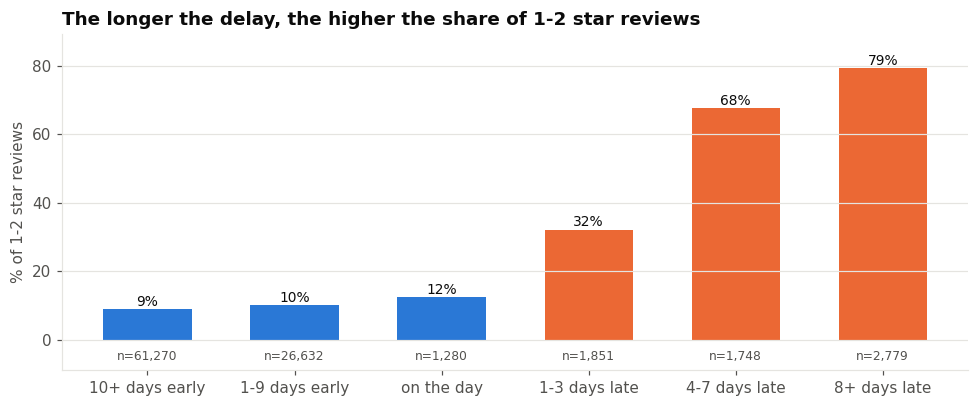

In [20]:
fig, ax = plt.subplots(figsize=(9, 3.8))
colors = [BLUE if "late" not in str(l) else ORANGE for l in dose.index]
bars = ax.bar(range(len(dose)), dose["pct_1_2_stars"], color=colors, width=0.6)
for i, (v, n) in enumerate(zip(dose["pct_1_2_stars"], dose["n"])):
    ax.text(i, v + 1, f"{v:.0f}%", ha="center", fontsize=9, color=INK)
    ax.text(i, -6, f"n={n:,}", ha="center", fontsize=8, color=INK2)
ax.set_xticks(range(len(dose)), dose.index)
ax.set_ylim(-9, max(dose["pct_1_2_stars"]) + 10)
ax.set_ylabel("% of 1-2 star reviews")
ax.grid(axis="x", visible=False)
ax.set_title("The longer the delay, the higher the share of 1-2 star reviews")
fig.tight_layout()
save(fig, "sat_low_reviews_by_delay.png")

**Finding:** A clear dose-response pattern: 1-2 star share is 9% for orders 10+ days early, 12% on the promised day, 32% at 1-3 days late, 68% at 4-7 days late and 79% at 8+ days late.

### C3. What share of all 1-2 star reviews come from late orders?

In [21]:
low = rev[rev["review_score"] <= 2]
share_late_in_low = (low["status"] == "late").mean()
share_late_overall = (rev["status"] == "late").mean()
print(f"late orders are {100*share_late_overall:.1f}% of reviewed orders "
      f"but {100*share_late_in_low:.1f}% of all 1-2 star reviews")

late orders are 6.7% of reviewed orders but 32.6% of all 1-2 star reviews


### C4. Sensitivity: remove reviews written before the order arrived

In [22]:
rev2 = rev[~rev["review_before_delivery"].astype(bool)]
a2 = rev2.loc[rev2["status"] == "late", "review_score"].to_numpy()
b2 = rev2.loc[rev2["status"] == "on time", "review_score"].to_numpy()
est2 = bootstrap_diff(a2, b2, n_boot=2000)
print(f"removed {len(rev) - len(rev2):,} reviews; late n={len(a2):,}, on-time n={len(b2):,}")
print(f"mean difference {est2[0]:.3f}, 95% CI [{est2[1]:.3f}, {est2[2]:.3f}]")

removed 4,970 reviews; late n=1,629, on-time n=88,961
mean difference -0.766, 95% CI [-0.840, -0.691]


**Finding (C3, C4):** 
Late orders are 6.7% of reviewed orders but **32.6% of all 1-2 star reviews**.
**Sensitivity:** removing the 4,970 reviews written before the order arrived removes most late-order reviews (late n falls from 6,378 to 1,629). The gap shrinks from -2.02 to **-0.77 stars (95% CI -0.84 to -0.69)** but stays clearly negative. So a large part of the headline gap comes from customers reviewing *while still waiting* - the dissatisfaction is about the delay itself; customers who review after a late delivery are still ~0.8 stars less satisfied.

## Part D - What this does and does not prove

1. **The 95% CI** (-2.06 to -1.98 stars): if we repeated the sampling many times, 95% of intervals built this way would contain the true difference in mean score between late and on-time orders. It is narrow because the samples are large.
2. **What it shows:** in this data, late delivery is strongly **associated** with lower review scores; the association is large, far beyond sampling noise, present within every large state, grows with the size of the delay, and survives removing reviews written before delivery (smaller, -0.77 stars).
3. **What it does NOT show:** that late delivery *causes* lower scores, or that cutting late deliveries would raise the average score by 2 stars. Customers who never left a review are not represented.
4. **Uncontrolled confounders:** product category, seller, product price/size, distance and freight cost, and the carrier - any of these can be linked to both lateness and satisfaction.
5. **Verdict on the hypothesis "late deliveries are associated with lower review scores": supported.** The size of the effect depends on when the review was written (-2.0 stars overall, -0.8 stars for reviews written after delivery).